# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mirzayasirabdullah07/llm-and-generative-ai-usage-analytics-dataset/genai_llm_usage_dataset_1000.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mirzayasirabdullah07/llm-and-generative-ai-usage-analytics-dataset/genai_llm_usage_dataset_1000.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,session_id,model_name,application_domain,task_type,prompt_length,total_tokens,temperature,top_p,rag_enabled,latency_sec,hallucination_flag,user_satisfaction,estimated_cost_usd,successful_response
0,1,GPT-4o,Healthcare,Summarization,1319,2455,0.17,0.87,0,3.76,0,4,0.0236,1
1,2,GPT-4o,Customer Support,Summarization,486,1425,0.76,0.51,0,2.36,1,5,0.0236,0
2,3,Gemma 3,Retail,Classification,1439,1648,0.63,0.64,0,3.68,1,4,0.0139,0
3,4,Gemma 3,Retail,Summarization,1662,2812,0.07,0.73,0,3.25,1,4,0.0374,0
4,5,Gemma 3,Finance,Classification,1452,1678,0.10,0.83,0,8.04,0,4,0.0171,0


## last Five row

In [4]:
df.tail()

,session_id,model_name,application_domain,task_type,prompt_length,total_tokens,temperature,top_p,rag_enabled,latency_sec,hallucination_flag,user_satisfaction,estimated_cost_usd,successful_response
995,996,Llama 3.1,Retail,QA,696,1044,1.46,0.95,0,3.99,1,4,0.0076,0
996,997,Qwen 2.5,Finance,RAG,227,1022,0.91,0.90,0,4.47,1,5,0.0026,0
997,998,Claude 3.7,Customer Support,QA,1571,2694,1.50,0.54,1,2.77,0,5,0.0465,1
998,999,Llama 3.1,Customer Support,Classification,1253,2451,0.71,0.76,0,5.21,1,4,0.0157,0
999,1000,Claude 3.7,Healthcare,Classification,482,1341,0.68,0.87,1,1.70,0,5,0.0112,1


## Shape of our dataset

In [5]:
df.shape

(1000, 14)

## List out all columns

In [6]:
df.columns

Index(['session_id', 'model_name', 'application_domain', 'task_type',
       'prompt_length', 'total_tokens', 'temperature', 'top_p', 'rag_enabled',
       'latency_sec', 'hallucination_flag', 'user_satisfaction',
       'estimated_cost_usd', 'successful_response'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

session_id               int64
model_name              object
application_domain      object
task_type               object
prompt_length            int64
total_tokens             int64
temperature            float64
top_p                  float64
rag_enabled              int64
latency_sec            float64
hallucination_flag       int64
user_satisfaction        int64
estimated_cost_usd     float64
successful_response      int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           1000 non-null   int64  
 1   model_name           1000 non-null   object 
 2   application_domain   1000 non-null   object 
 3   task_type            1000 non-null   object 
 4   prompt_length        1000 non-null   int64  
 5   total_tokens         1000 non-null   int64  
 6   temperature          1000 non-null   float64
 7   top_p                1000 non-null   float64
 8   rag_enabled          1000 non-null   int64  
 9   latency_sec          1000 non-null   float64
 10  hallucination_flag   1000 non-null   int64  
 11  user_satisfaction    1000 non-null   int64  
 12  estimated_cost_usd   1000 non-null   float64
 13  successful_response  1000 non-null   int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 109.5+ KB


## Check Null Value

In [9]:
df.isnull().sum()

session_id             0
model_name             0
application_domain     0
task_type              0
prompt_length          0
total_tokens           0
temperature            0
top_p                  0
rag_enabled            0
latency_sec            0
hallucination_flag     0
user_satisfaction      0
estimated_cost_usd     0
successful_response    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,session_id,prompt_length,total_tokens,temperature,top_p,rag_enabled,latency_sec,hallucination_flag,user_satisfaction,estimated_cost_usd,successful_response
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1022.780000,1636.763000,0.74728,0.74207,0.502000,5.368310,0.507000,4.345000,0.018026,0.202000
std,288.819436,574.062391,681.390085,0.42545,0.14234,0.500246,2.375312,0.500201,0.581647,0.011971,0.401693
min,1.000000,12.000000,71.000000,0.00000,0.50000,0.000000,0.310000,0.000000,3.000000,0.000500,0.000000
25%,250.750000,520.750000,1118.000000,0.37000,0.62000,0.000000,3.300000,0.000000,4.000000,0.008400,0.000000
50%,500.500000,1056.000000,1635.500000,0.74000,0.74000,1.000000,5.460000,1.000000,4.000000,0.015400,0.000000
75%,750.250000,1493.250000,2142.250000,1.11000,0.86000,1.000000,7.370000,1.000000,5.000000,0.024900,0.000000
max,1000.000000,2000.000000,3158.000000,1.50000,1.00000,1.000000,10.440000,1.000000,5.000000,0.060300,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

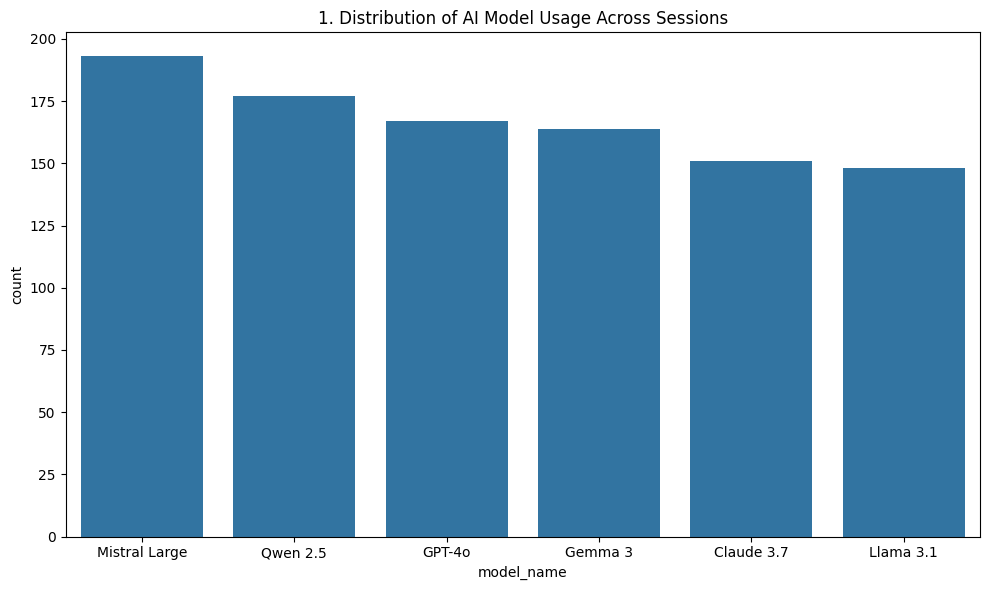

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='model_name', order=df['model_name'].value_counts().index)
plt.title(f'{plot_no}. Distribution of AI Model Usage Across Sessions')
show_fig()
plot_no += 1

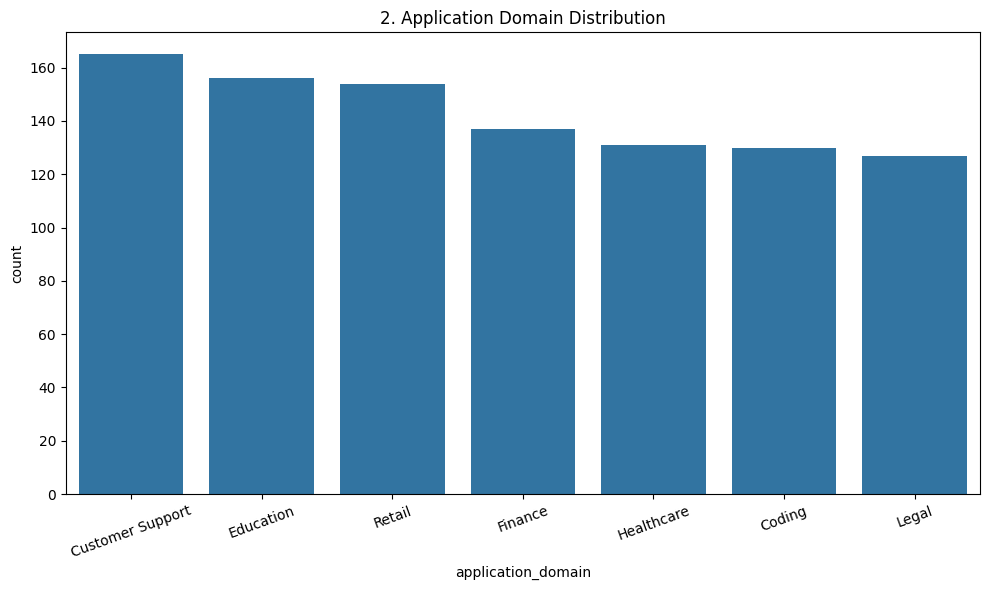

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='application_domain', order=df['application_domain'].value_counts().index)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Application Domain Distribution')
show_fig()
plot_no += 1

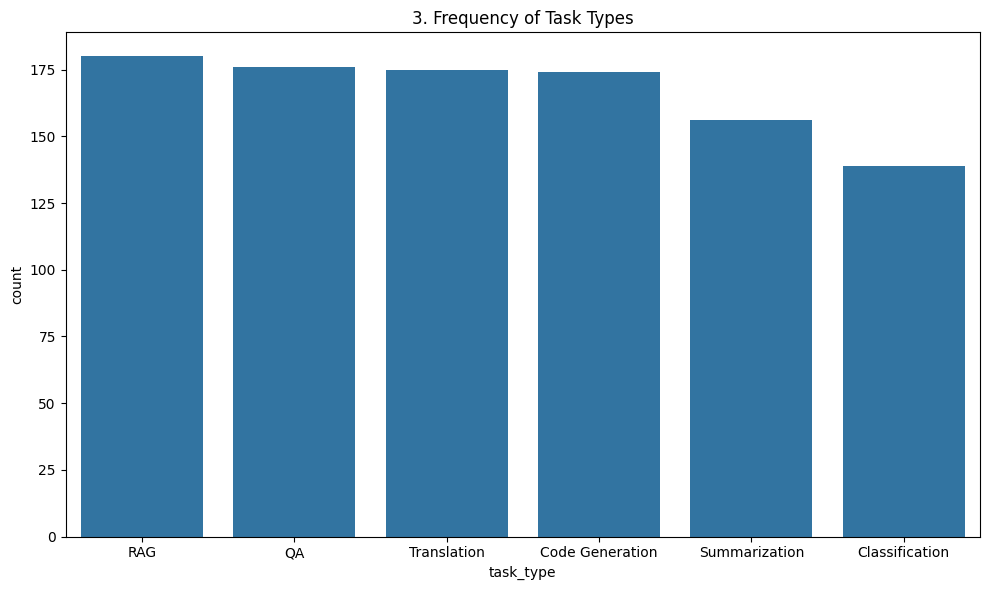

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='task_type', order=df['task_type'].value_counts().index)
plt.title(f'{plot_no}. Frequency of Task Types')
show_fig()
plot_no += 1

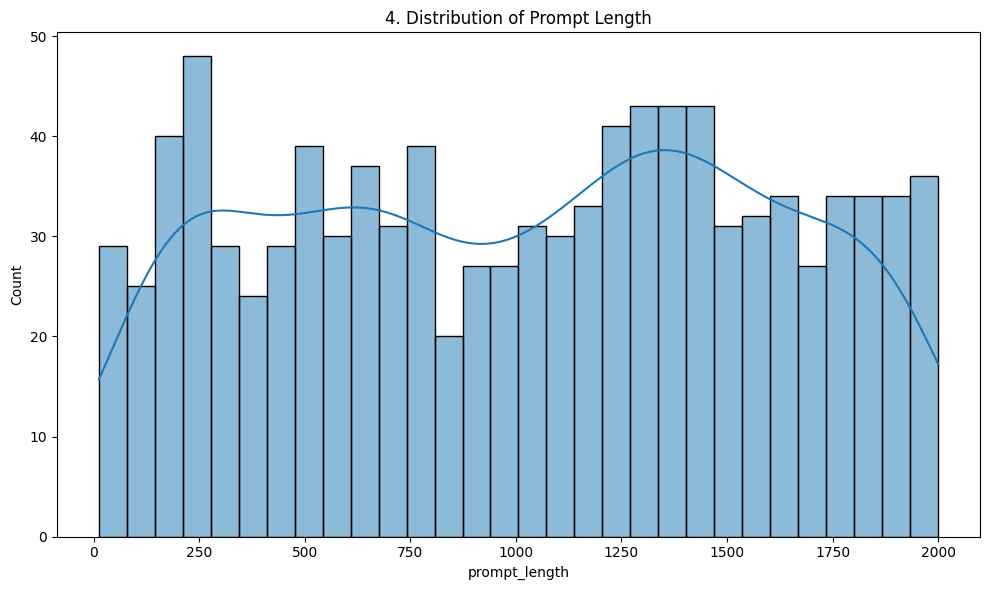

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['prompt_length'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Prompt Length')
show_fig()
plot_no += 1

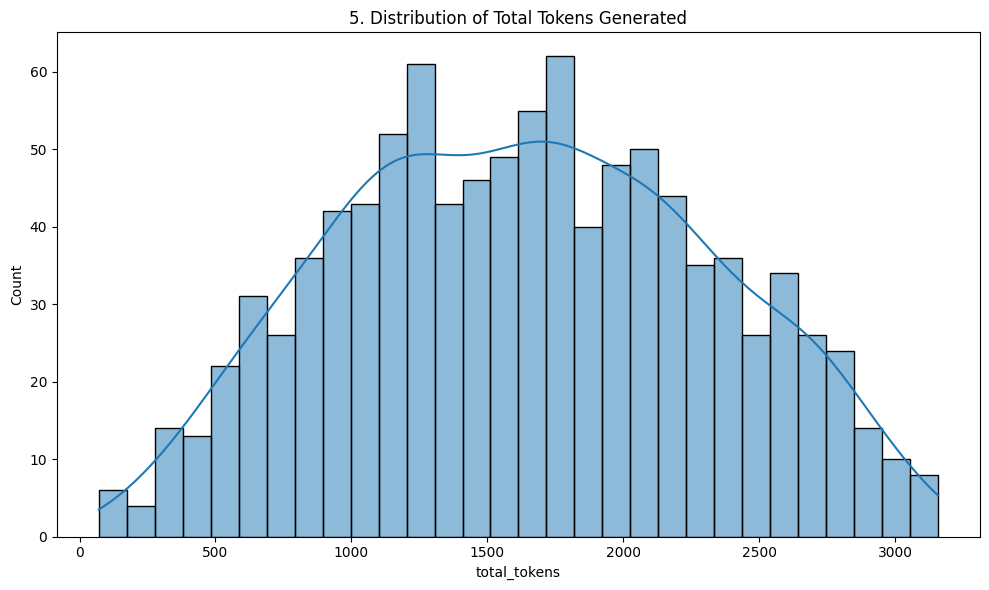

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['total_tokens'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Total Tokens Generated')
show_fig()
plot_no += 1

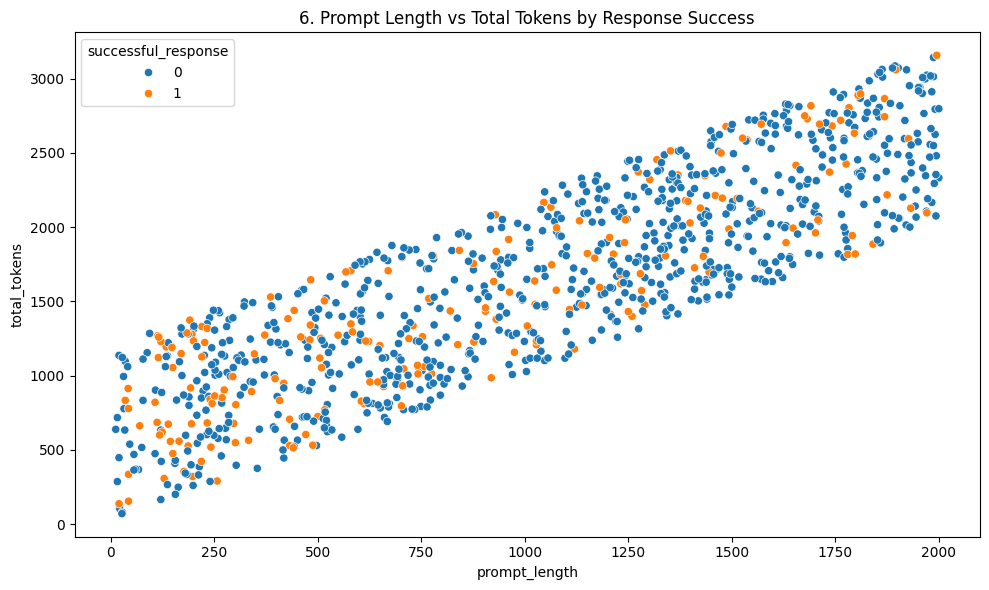

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='prompt_length', y='total_tokens', hue='successful_response')
plt.title(f'{plot_no}. Prompt Length vs Total Tokens by Response Success')
show_fig()
plot_no += 1

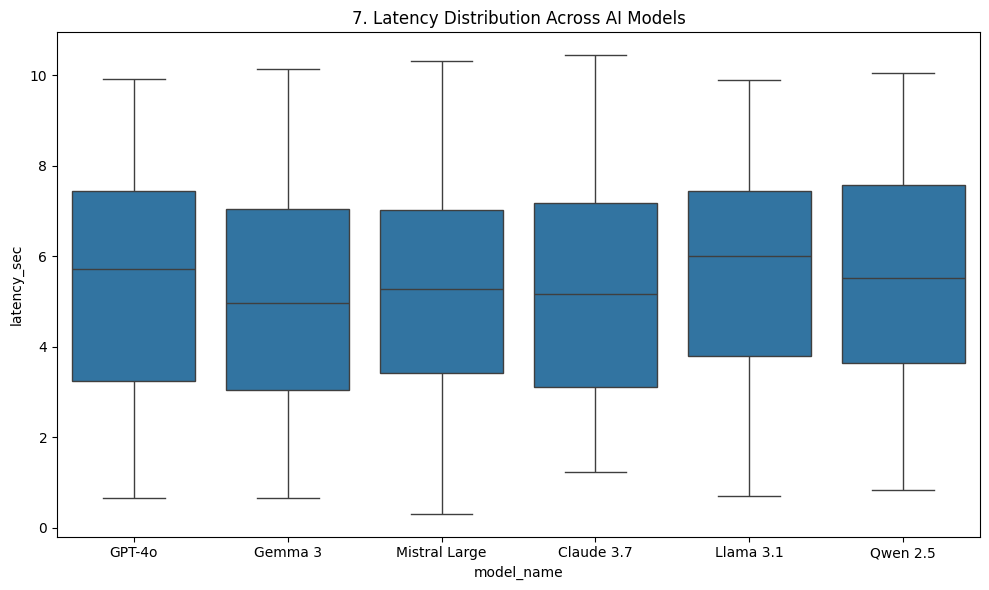

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='model_name', y='latency_sec')
plt.title(f'{plot_no}. Latency Distribution Across AI Models')
show_fig()
plot_no += 1

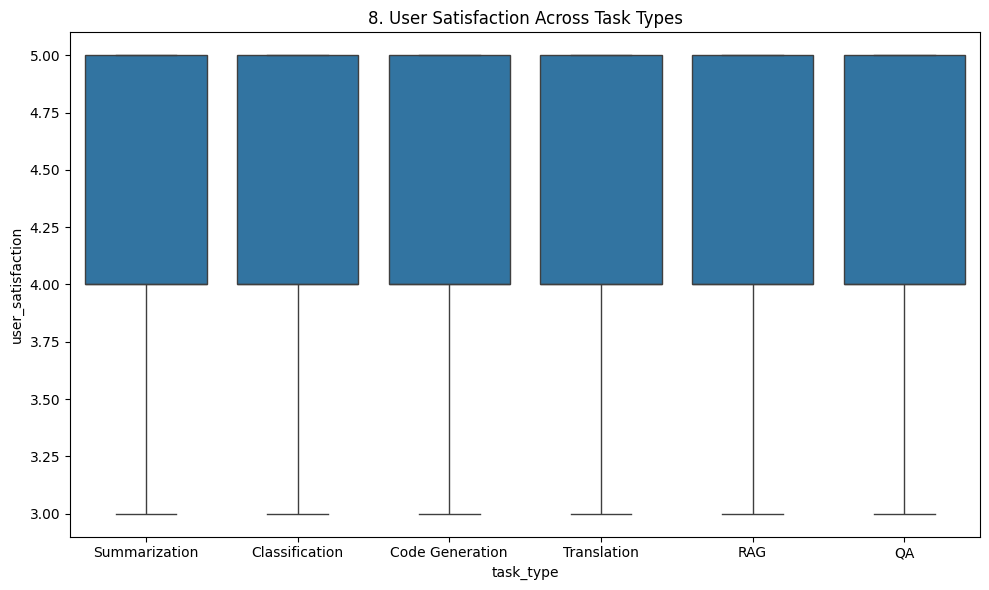

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='task_type', y='user_satisfaction')
plt.title(f'{plot_no}. User Satisfaction Across Task Types')
show_fig()
plot_no += 1

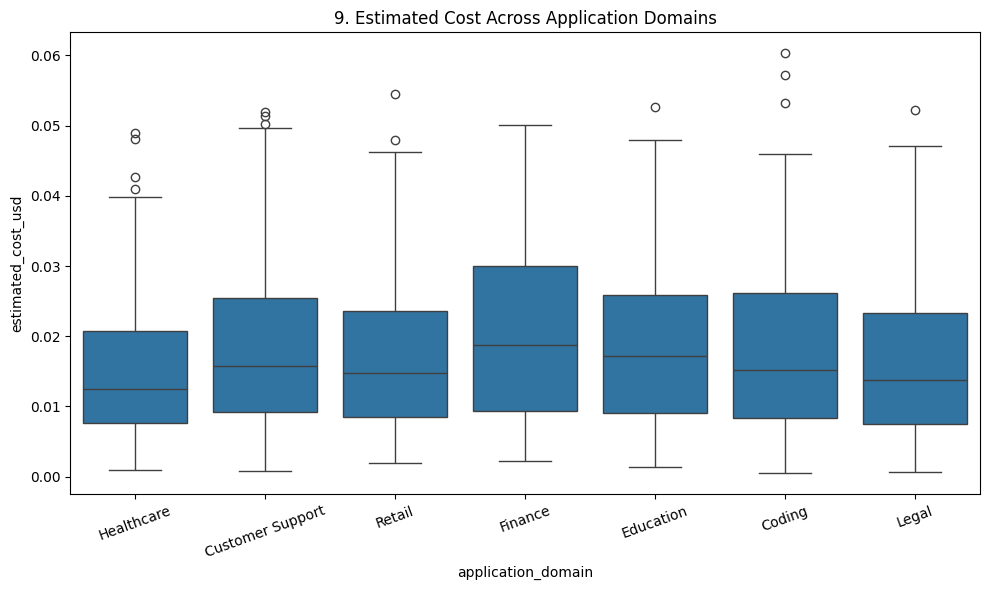

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='application_domain', y='estimated_cost_usd')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Estimated Cost Across Application Domains')
show_fig()
plot_no += 1

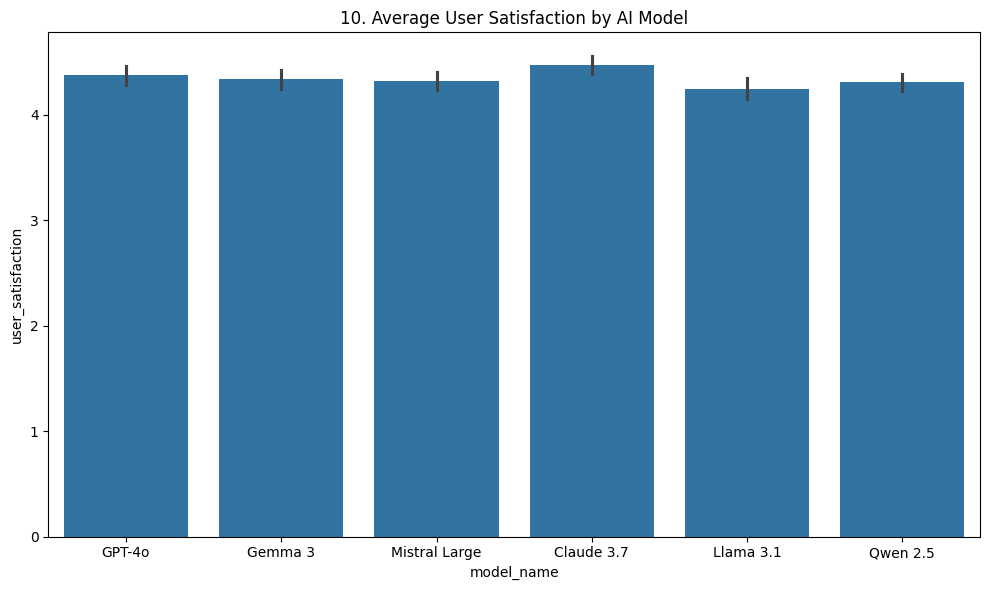

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='model_name', y='user_satisfaction', estimator='mean')
plt.title(f'{plot_no}. Average User Satisfaction by AI Model')
show_fig()
plot_no += 1

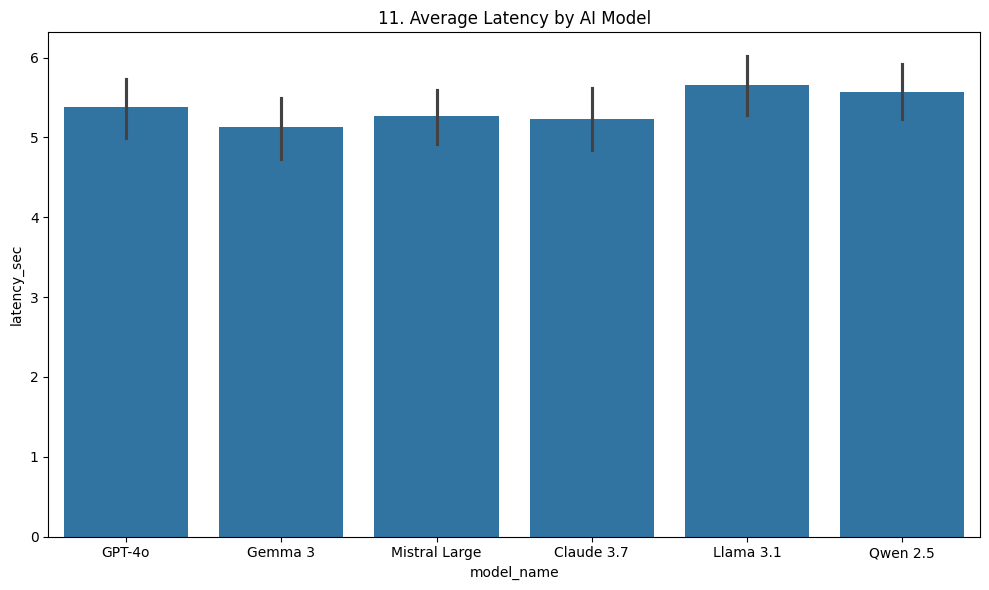

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='model_name', y='latency_sec', estimator='mean')
plt.title(f'{plot_no}. Average Latency by AI Model')
show_fig()
plot_no += 1

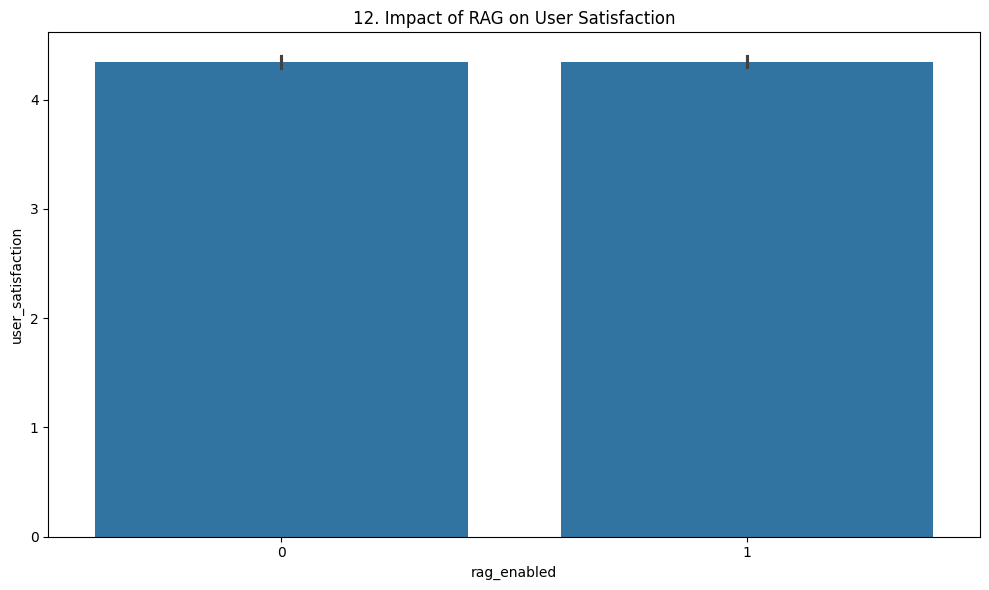

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='rag_enabled', y='user_satisfaction', estimator='mean')
plt.title(f'{plot_no}. Impact of RAG on User Satisfaction')
show_fig()
plot_no += 1

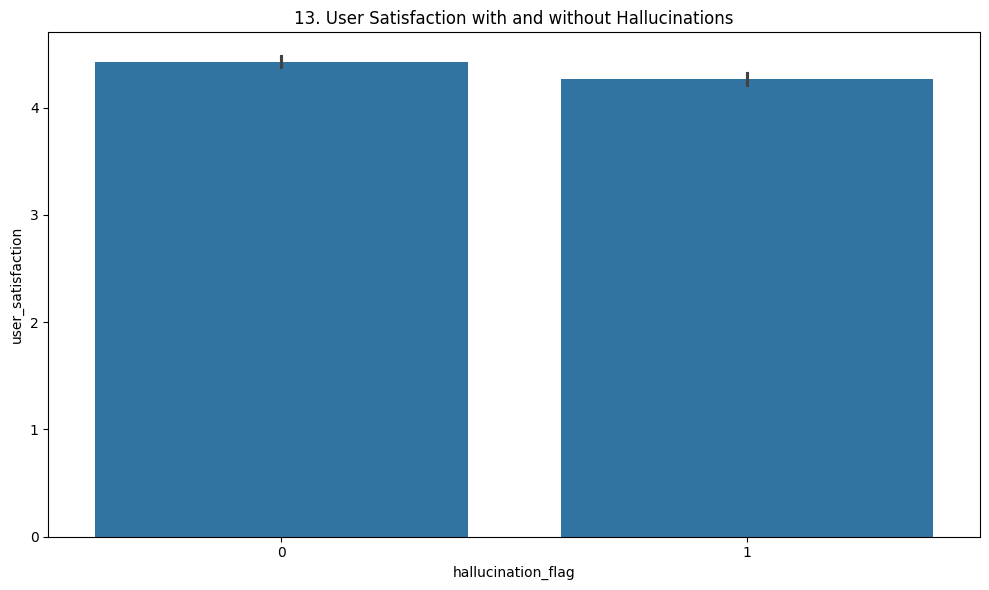

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='hallucination_flag', y='user_satisfaction', estimator='mean')
plt.title(f'{plot_no}. User Satisfaction with and without Hallucinations')
show_fig()
plot_no += 1

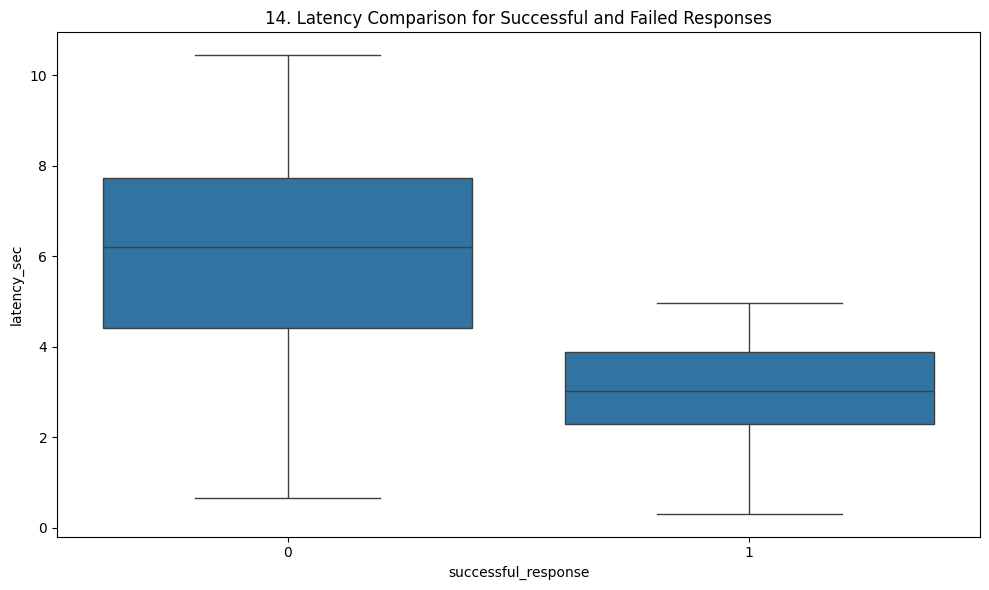

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='successful_response', y='latency_sec')
plt.title(f'{plot_no}. Latency Comparison for Successful and Failed Responses')
show_fig()
plot_no += 1

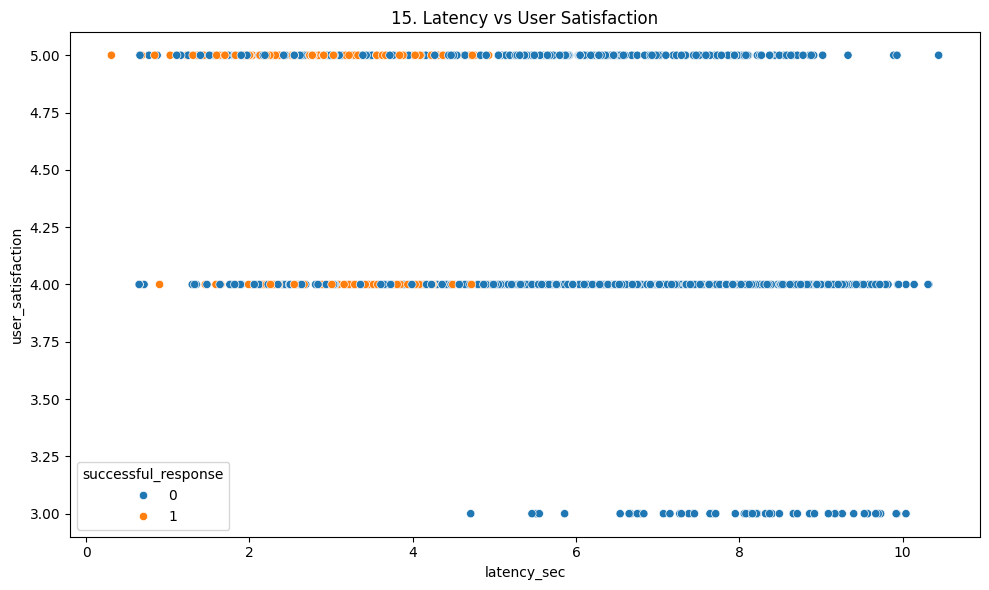

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='latency_sec', y='user_satisfaction', hue='successful_response')
plt.title(f'{plot_no}. Latency vs User Satisfaction')
show_fig()
plot_no += 1

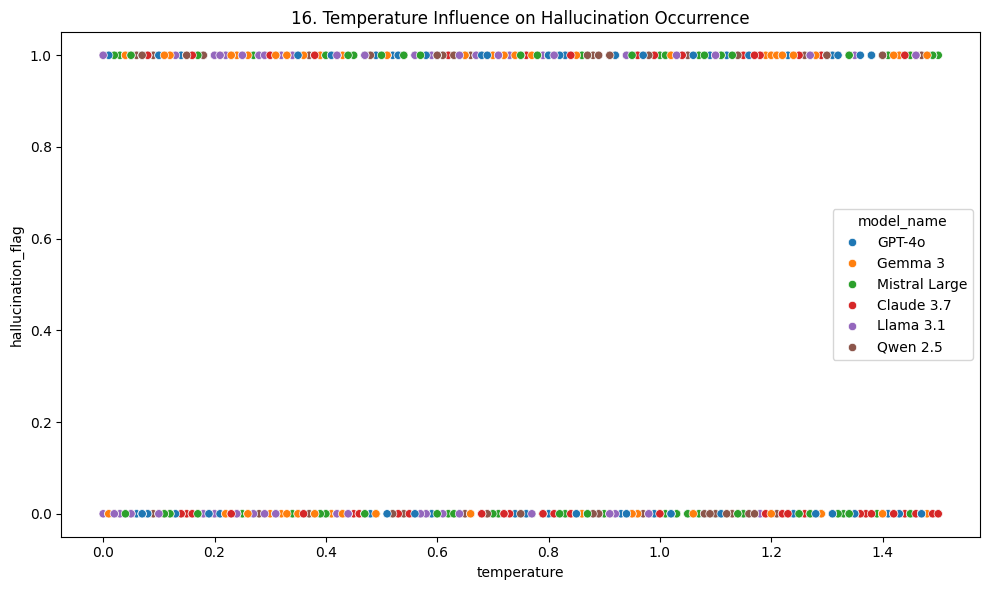

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature', y='hallucination_flag', hue='model_name')
plt.title(f'{plot_no}. Temperature Influence on Hallucination Occurrence')
show_fig()
plot_no += 1

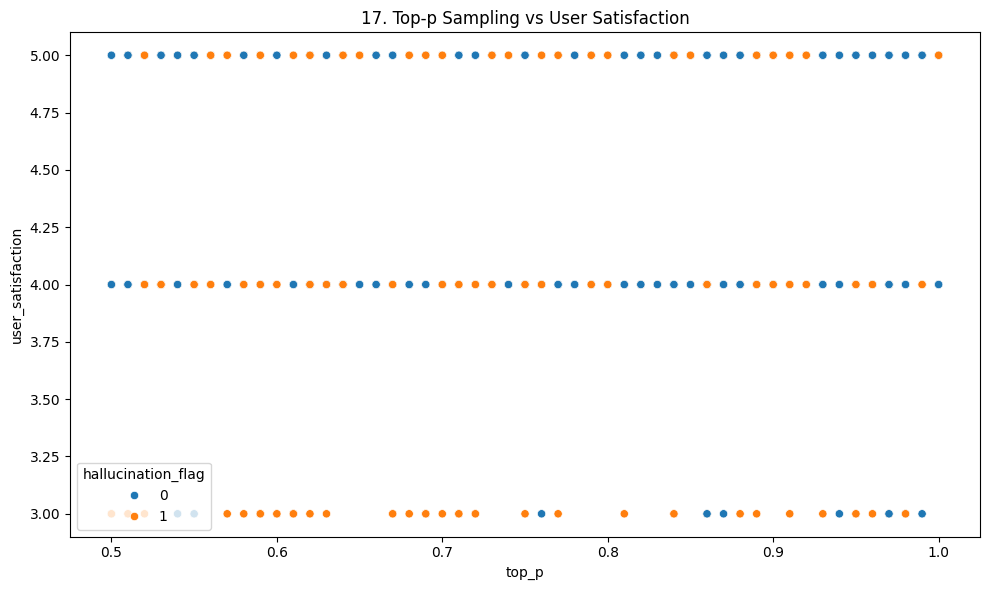

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='top_p', y='user_satisfaction', hue='hallucination_flag')
plt.title(f'{plot_no}. Top-p Sampling vs User Satisfaction')
show_fig()
plot_no += 1

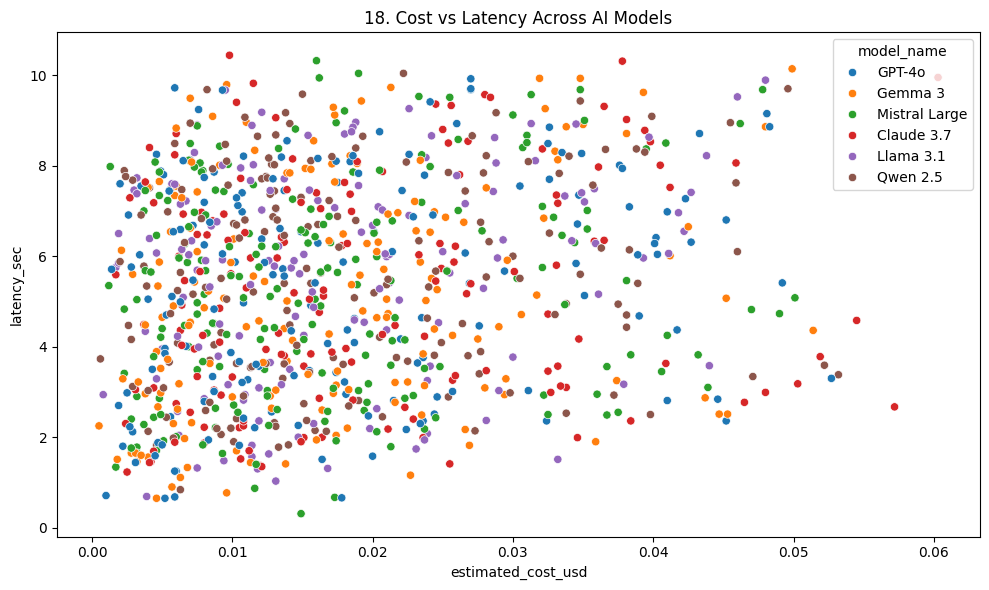

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='estimated_cost_usd', y='latency_sec', hue='model_name')
plt.title(f'{plot_no}. Cost vs Latency Across AI Models')
show_fig()
plot_no += 1

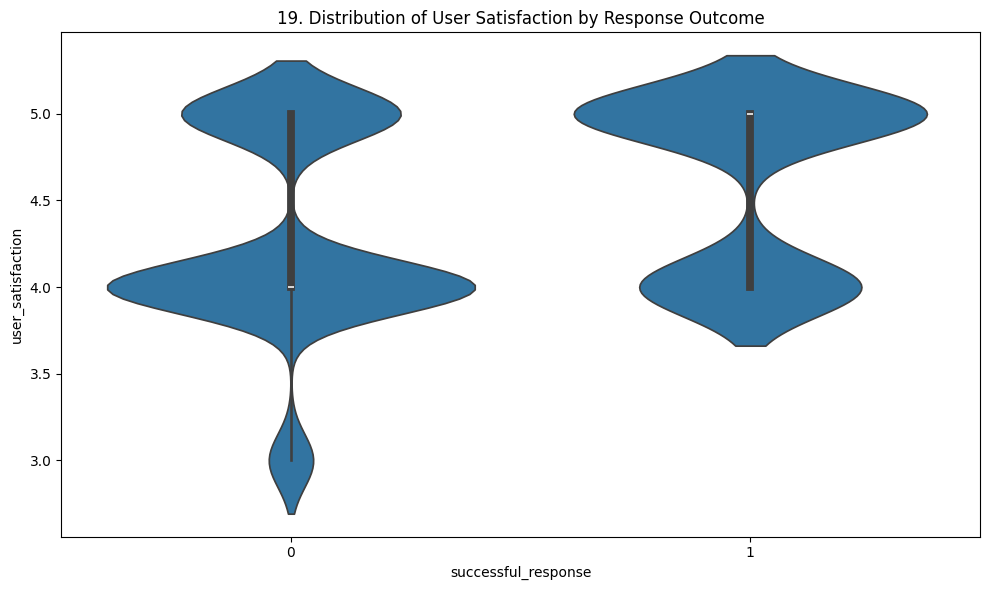

In [31]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='successful_response', y='user_satisfaction')
plt.title(f'{plot_no}. Distribution of User Satisfaction by Response Outcome')
show_fig()
plot_no += 1

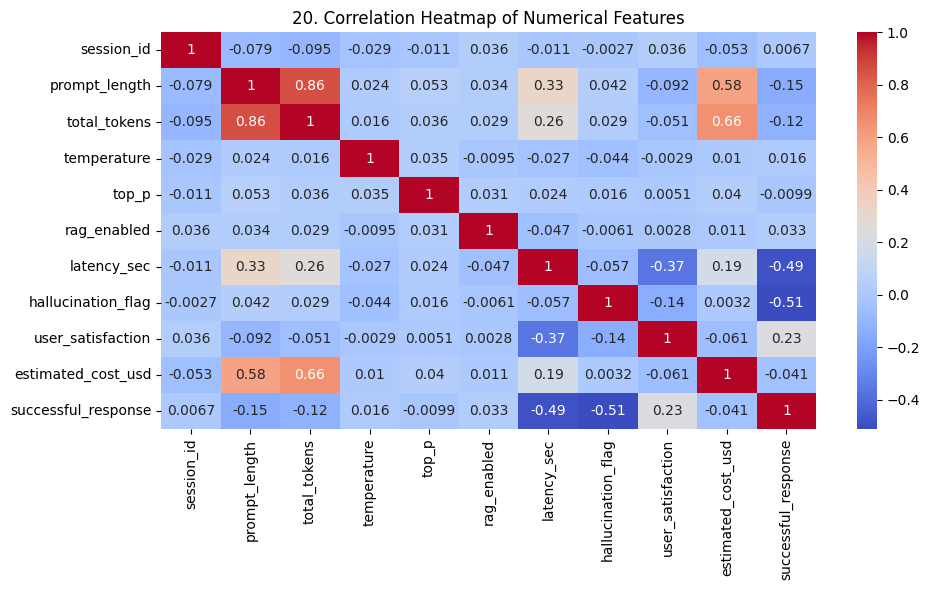

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Define features and target

In [33]:
X = df.drop(columns=['successful_response'])
y = df['successful_response']

## Separate numerical and categorical columns

In [34]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Create preprocessing pipeline

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

## Split dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create SVM classification model

In [37]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

## Train model

In [38]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['session_id', 'prompt_length', 'total_tokens', 'temperature', 'top_p',
       'rag_enabled', 'latency_sec', 'hallucination_flag', 'user_satisfaction',
       'estimated_cost_usd'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['model_name', 'application_domain', 'task_type'], dtype='object'))])),
                ('classifier', SVC())])

## Predict on test data

In [39]:
y_pred = model.predict(X_test)

## Print model accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

Accuracy Score: 0.9800


## Plot confusion matrix

<Figure size 600x500 with 0 Axes>

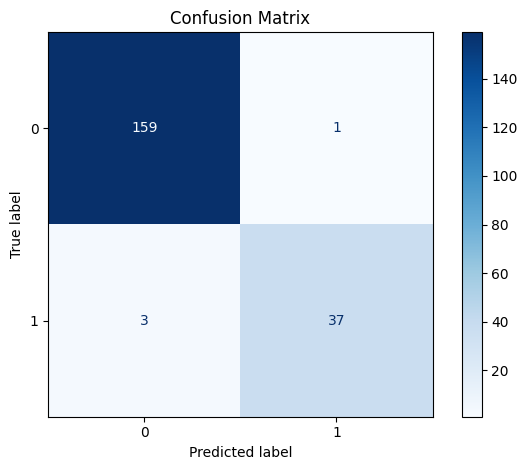

In [41]:
fig = plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()